In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/Ayobami Adeyemo/Downloads/job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
# Initial Inspection
print(f"Data Shape: {df.shape}")
display(df.head())
display(df.tail(2))

Data Shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [5]:
# Let's standardize a column name just to see how it works
df = df.rename(columns={'job_title': 'Job_Title', 'experience_years': 'Years_of_Experience', 'education_level': 'Education_Level', 'skills_count':'Skills_Count', 'industry': 'Industry', 'company_size': 'Company_Size', 'location': 'Location', 'remote_work': 'Remote_Work', 'certifications': 'Certifications', 'salary': 'Salary'})
df.columns

Index(['Job_Title', 'Years_of_Experience', 'Education_Level', 'Skills_Count',
       'Industry', 'Company_Size', 'Location', 'Remote_Work', 'Certifications',
       'Salary'],
      dtype='str')

In [6]:
missing_values = df.isnull().sum()
print(missing_values)

Job_Title              0
Years_of_Experience    0
Education_Level        0
Skills_Count           0
Industry               0
Company_Size           0
Location               0
Remote_Work            0
Certifications         0
Salary                 0
dtype: int64


In [7]:
print ("Missing values in the salary column:", df['Salary'].isnull().sum())
mean_salary = df['Salary'].mean()
print(f"The Mean Salary is ${mean_salary}")

Missing values in the salary column: 0
The Mean Salary is $145718.080524


In [8]:
# 2. The Median
median_salary = df['Salary'].median()
print(f"The median salary value: ${median_salary}")

The median salary value: $143453.0


In [9]:
# 3. The Groupped Median
groupped_median = df.groupby('Job_Title')['Salary'].median()
display(groupped_median)

Job_Title
AI Engineer                  171674.0
Backend Developer            136678.0
Business Analyst             120562.0
Cloud Engineer               150005.0
Cybersecurity Analyst        146737.0
Data Analyst                 118079.5
Data Scientist               145231.5
DevOps Engineer              148021.0
Frontend Developer           130619.0
Machine Learning Engineer    160933.0
Product Manager              155655.5
Software Engineer            139432.5
Name: Salary, dtype: float64

In [10]:
missing_salary = df[df['Salary'].isnull()]
display(missing_salary[['Education_Level', 'Salary']])

,Education_Level,Salary


In [11]:
education_salary = df.groupby('Education_Level')['Salary'].median()
display(education_salary)

Education_Level
Bachelor       140631.5
Diploma        135283.0
High School    129663.0
Master         151396.5
PhD            162005.0
Name: Salary, dtype: float64

In [12]:
location_numbers = df['Location'].value_counts()
display(location_numbers)

Location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

In [13]:
from matplotlib import pyplot as plt
import seaborn as sns

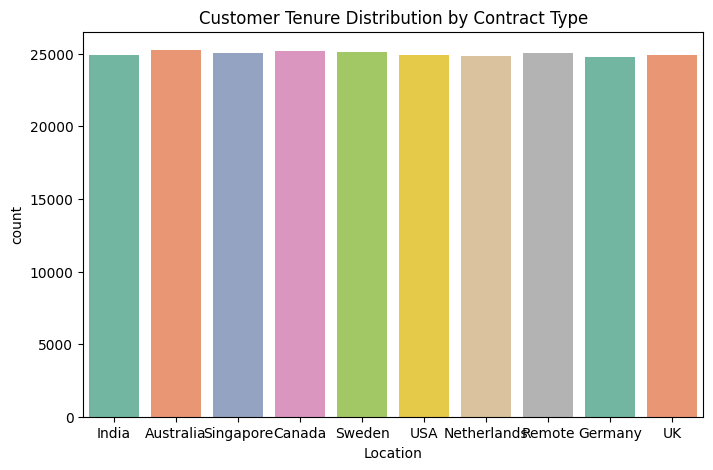

In [14]:
plt.figure(figsize=(8, 5))
# Write your sns.boxplot code here:
sns.countplot(data=df, x='Location', hue='Location', palette='Set2', legend=False)

plt.title('Customer Tenure Distribution by Contract Type')
plt.show()

In [15]:
df.describe()

,Years_of_Experience,Skills_Count,Certifications,Salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [16]:
 # Specific Column Statistics
 print(f"Average Years of Experience: {df['Years_of_Experience'].mean()} years")

Average Years of Experience: 10.005408 years


In [17]:
df.groupby('Job_Title')['Certifications'].median()

Job_Title
AI Engineer                  3.0
Backend Developer            2.0
Business Analyst             2.0
Cloud Engineer               3.0
Cybersecurity Analyst        2.0
Data Analyst                 3.0
Data Scientist               3.0
DevOps Engineer              2.0
Frontend Developer           3.0
Machine Learning Engineer    2.0
Product Manager              2.0
Software Engineer            2.0
Name: Certifications, dtype: float64

In [18]:
round(df.groupby('Job_Title')['Certifications'].mean())

Job_Title
AI Engineer                  2.0
Backend Developer            2.0
Business Analyst             3.0
Cloud Engineer               3.0
Cybersecurity Analyst        2.0
Data Analyst                 3.0
Data Scientist               3.0
DevOps Engineer              2.0
Frontend Developer           2.0
Machine Learning Engineer    2.0
Product Manager              2.0
Software Engineer            2.0
Name: Certifications, dtype: float64

In [19]:
df_df = df.groupby('Industry')['Salary'].mean()
display(df_df)

Industry
Consulting       145451.638293
Education        145993.564547
Finance          145801.639468
Government       145613.869242
Healthcare       145759.995702
Manufacturing    145530.603301
Media            145891.271071
Retail           145399.699408
Technology       145863.808377
Telecom          145876.511967
Name: Salary, dtype: float64

In [20]:
df['Industry'].value_counts()

Industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

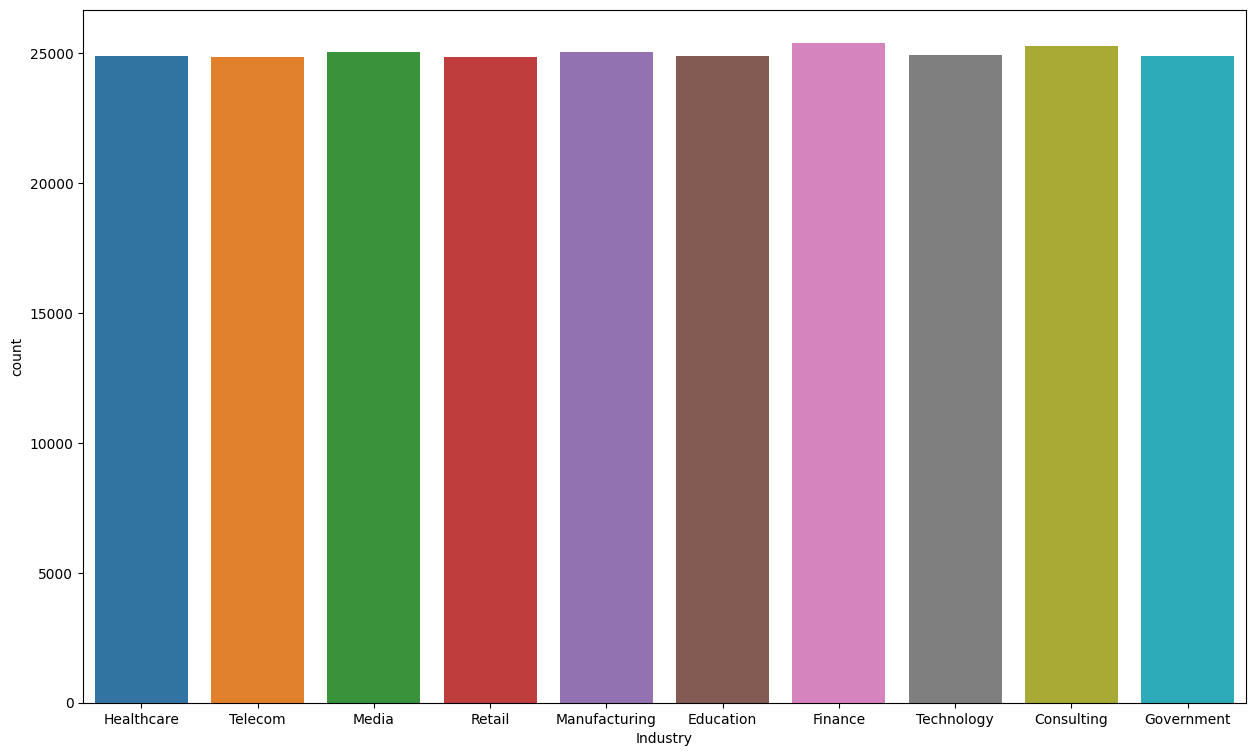

In [21]:
plt.figure(figsize=(15, 9))
#plt.plot(df_df['Salary'], df_df['Industry'], marker='o', linestyle='-', color='b', label='y = x²')
sns.countplot(data=df, x='Industry', hue='Industry', legend=False)
plt.show()

In [22]:
# MULTIVARIATE AGGREGATION (Groupby)
# What is the averahe salary for workers who work in office or not or hybrid

# Step 1: Group the data in terms of Remote Work whether 'Yes', 'No' and 'Hybrid'
groupby_remote_work = df.groupby('Remote_Work')

# Step 2: Look only at the 'Salary' column and compute the average for each role
average_salary = groupby_remote_work['Salary'].mean()


print ('Average Salary for type of remote_work:')
average_salary


Average Salary for type of remote_work:


Remote_Work
Hybrid    143969.899839
No        143932.300941
Yes       149279.589822
Name: Salary, dtype: float64

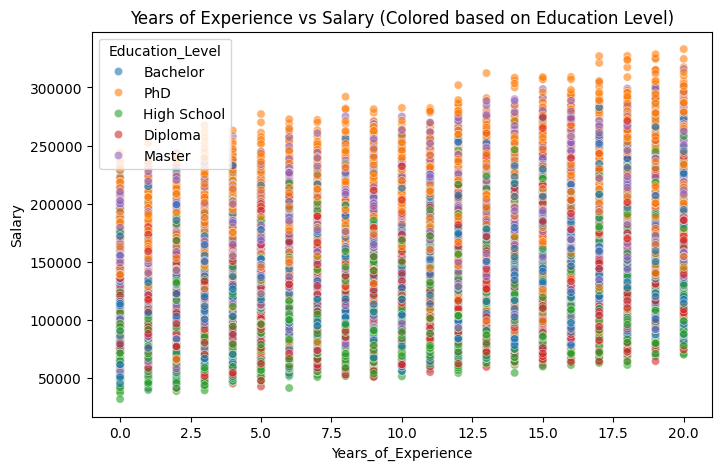

In [23]:
# SCATTER PLOT (Relationships between two numerical columns)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Years_of_Experience', y='Salary', hue='Education_Level', alpha=0.6)
plt.title('Years of Experience vs Salary (Colored based on Education Level)')
plt.show()

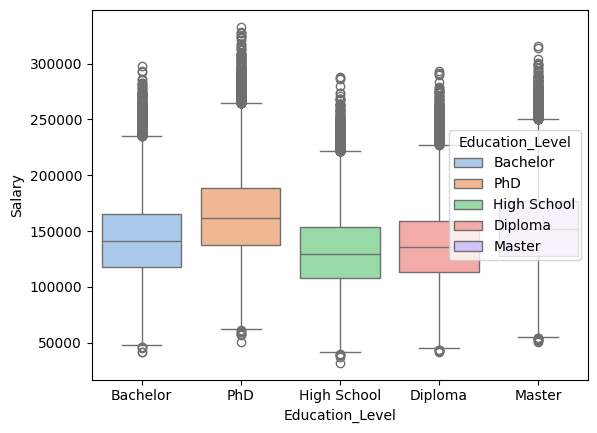

In [25]:
# OUTLIER DETECTION ()
plt.figure()
sns.boxplot(data=df, x='Education_Level', y='Salary', hue='Education_Level', palette='pastel', legend=True)
plt.show()

## Hat 4: The ML Engineer (Model Preparation)
**Goal:** Ensure the data won't break our predictive models (Class Imbalance, Leakage, Multicollinearity).

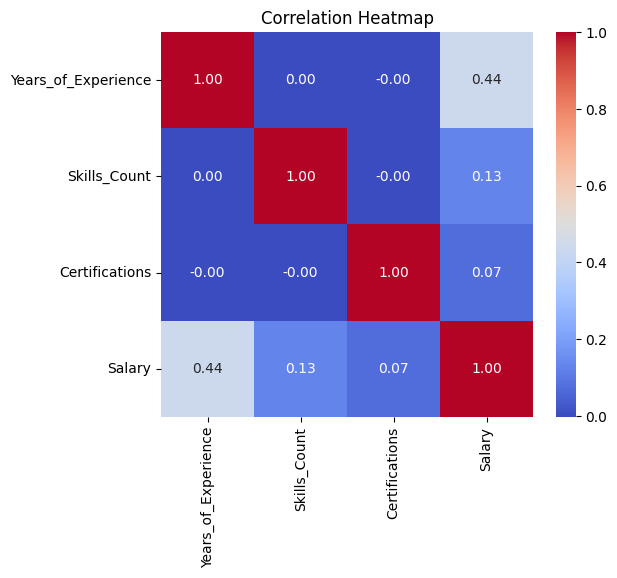

In [26]:
# MULTICOLLINEARITY (Correlation Matrix & Heatmap)
# ML models struggle if features are perfectly correlated with each other.

# Step 1: We can only calculate correlation on numbers, not text.
# Let's create a dataframe that only contains the numerical columns.
numeric_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## More work to do here or basically talk about my hypothesis and get a possible model to use and train for prediction

### High Cardinality
#### **Cardinality** = The number of unique values in a column.
#### If a text column has too many unique values, One-Hot Encoding will create thousands of new columns and crash our Machine Learning model (The Curse of Dimensionality).
#### * **Pure IDs (1-to-1):** Drop them.
#### * **High Cardinality Categories (like Zip Codes):** Aggregate them!


In [27]:
# THE CARDINALITY CHECK
print("Unique values per text column:")
text_columns = df.select_dtypes(include='object')
print(text_columns.nunique())

Unique values per text column:
Job_Title          12
Education_Level     5
Industry           10
Company_Size        5
Location           10
Remote_Work         3
dtype: int64


C:\Users\Ayobami Adeyemo\AppData\Local\Temp\ipykernel_23968\1250501295.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object')


In [28]:
education_level = df.groupby('Education_Level')['Salary'].median()
display(education_level)

Education_Level
Bachelor       140631.5
Diploma        135283.0
High School    129663.0
Master         151396.5
PhD            162005.0
Name: Salary, dtype: float64

In [29]:
df.head()

,Job_Title,Years_of_Experience,Education_Level,Skills_Count,Industry,Company_Size,Location,Remote_Work,Certifications,Salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [30]:
X = df.drop(['Salary'], axis=1 )
y = df['Salary']

X = pd.get_dummies(X, columns=['Education_Level', 'Job_Title', 'Remote_Work', 'Company_Size', 'Location', 'Industry'], drop_first=True)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape[0]}")
print(f"X_test shape: {X_test.shape[0]}")

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

X_train shape: 200000
X_test shape: 50000


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9608646103591565
MAE: 5690.641167641905
MSE: 54392854.85840806


In [33]:
print(f"Training Accuracy: {model.score(X_train, y_train)}")
print(f"Testing Accuracy: {model.score(X_test, y_test)}")

Training Accuracy: 0.9944914809920107
Testing Accuracy: 0.9608646103591565


In [36]:
#from sklearn.model_selection import cross_val_score
#scores = cross_val_score(model, X, y, cv=5, scoring='r2')
#print(scores.mean())

In [37]:
import pandas as pd
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

Years_of_Experience                    0.200267
Location_India                         0.181683
Location_USA                           0.075859
Company_Size_Startup                   0.061069
Education_Level_PhD                    0.061046
Company_Size_Small                     0.050648
Job_Title_Data Analyst                 0.044634
Company_Size_Medium                    0.043637
Job_Title_Business Analyst             0.042349
Location_Canada                        0.034379
Education_Level_Master                 0.028925
Skills_Count                           0.025366
Location_UK                            0.021546
Job_Title_Frontend Developer           0.021023
Company_Size_Large                     0.014787
Job_Title_Backend Developer            0.011713
Location_Germany                       0.011644
Certifications                         0.010057
Job_Title_Software Engineer            0.009610
Education_Level_High School            0.006292
Job_Title_Data Scientist               0

In [38]:
print(X.columns)

Index(['Years_of_Experience', 'Skills_Count', 'Certifications',
       'Education_Level_Diploma', 'Education_Level_High School',
       'Education_Level_Master', 'Education_Level_PhD',
       'Job_Title_Backend Developer', 'Job_Title_Business Analyst',
       'Job_Title_Cloud Engineer', 'Job_Title_Cybersecurity Analyst',
       'Job_Title_Data Analyst', 'Job_Title_Data Scientist',
       'Job_Title_DevOps Engineer', 'Job_Title_Frontend Developer',
       'Job_Title_Machine Learning Engineer', 'Job_Title_Product Manager',
       'Job_Title_Software Engineer', 'Remote_Work_No', 'Remote_Work_Yes',
       'Company_Size_Large', 'Company_Size_Medium', 'Company_Size_Small',
       'Company_Size_Startup', 'Location_Canada', 'Location_Germany',
       'Location_India', 'Location_Netherlands', 'Location_Remote',
       'Location_Singapore', 'Location_Sweden', 'Location_UK', 'Location_USA',
       'Industry_Education', 'Industry_Finance', 'Industry_Government',
       'Industry_Healthcare', 'Indu

In [39]:
new_data = pd.DataFrame({
    'Years_of_Experience': [5],
    'Skills_Count': [10],
    'Certifications': [10],
    'Education_Level': ['Bachelor'],
    'Job_Title': ['Data Scientist'],
    'Remote_Work': ['Hybrid'],
    'Company_Size': ['Medium'],
    'Location': ['New York'],
    'Industry': ['Tech']
})

In [40]:
new_data_encoded = pd.get_dummies(new_data, drop_first=True)
new_data_encoded = new_data_encoded.reindex(columns=X.columns, fill_value=0)
prediction = model.predict(new_data_encoded)
print(f"Predicted Salary: ${prediction[0]:.2f}")

Predicted Salary: $174150.53


In [41]:
new_data_1 = pd.DataFrame({
    'Years_of_Experience': [2],
    'Skills_Count': [10],
    'Certifications': [1],
    'Education_Level': ['High School'],
    'Job_Title': ['Data Analyst'],
    'Remote_Work': ['Yes'],
    'Company_Size': ['Large'],
    'Location': ['New York'],
    'Industry': ['Healthcare']
})

In [66]:
new_data_encoded_1 = pd.get_dummies(new_data_1, drop_first=True)
new_data_encoded_1 = new_data_encoded_1.reindex(columns=X.columns, fill_value=0)
prediction_1 = model.predict(new_data_encoded_1)
print(f"Predicted Salary: ${prediction_1[0]:.2f}")

Predicted Salary: $161114.48


In [67]:
df = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

print(df.head(20))
print(df.tail(10))

    Actual  Predicted
0   164009  156527.92
1    79594  102989.06
2    74090   70285.91
3   177193  157643.95
4   120012  115459.76
5   163369  182102.34
6   111889  111012.12
7    75418   76849.07
8   103067   98305.66
9   190692  178625.45
10  114616  121357.15
11  213768  212021.47
12  126256  128861.10
13   99105  104717.30
14  277977  258388.75
15  153683  155671.47
16  235839  239920.84
17  149179  158740.65
18  130145  127438.01
19  171868  164698.75
       Actual  Predicted
49990  121157  119953.14
49991  187826  186386.03
49992  132007  143745.73
49993  149250  160453.04
49994   82186   84479.01
49995  136275  141471.26
49996  168515  175457.66
49997  176232  154188.31
49998  152933  150348.44
49999  116585  118949.42
